# 🤖 Entraînement du modèle RNN pour classification de sentiments

## 🎯 Objectif
Construire et entraîner un réseau de neurones récurrent (RNN) bidirectionnel pour classifier les critiques de films IMDB en sentiments positifs (1) ou négatifs (0).

## 📥 Entrée (depuis l'étape 2)
- `data/X_train.npy`, `data/X_test.npy` : séquences encodées (25 000 × 200)
- `data/y_train.npy`, `data/y_test.npy` : labels
- `data/vocab.pkl` : vocabulaire (non utilisé directement ici)

## 📤 Sorties générées
- `data/rnn_model.pth` : modèle entraîné
- `data/rnn_train_losses.npy`, `data/rnn_train_accs.npy` : historique
- `data/rnn_training_curves.png` : visualisation

## 🏗️ Architecture du modèle
| Couche | Paramètres |
|--------|-------------|
| Embedding | vocab_size=20 000, dim=128, padding_idx=0 |
| RNN | 2 couches, hidden_dim=256, bidirectionnel, dropout=0.3 |
| Dropout | 0.5 |
| Linear | hidden_dim*2 → 1 |

## ⚙️ Hyperparamètres
- Batch size : 64
- Learning rate : 0.0005
- Epochs : 10
- Gradient clipping : 1.0
- Longueur max : 200 mots (puis 100 dans la cellule problématique)

## 📚 Table des matières
- [Installations et imports](#installations-et-imports)
- [Chargement des données](#chargement-des-données)
- [Architecture du modèle RNN](#architecture-du-modèle-rnn)
- [Entraînement](#entraînement)
- [Courbe de loss + sauvegarde](#courbe-de-loss--sauvegarde)

#  Installations et imports

In [1]:
import sys
!{sys.executable} -m pip install torch --quiet

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import time

print(f"✅ PyTorch version : {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device utilisé  : {device}")

✅ PyTorch version : 2.11.0+cpu
✅ Device utilisé  : cpu


#  Chargement des données

In [2]:
# Chargement des fichiers préparés à l'étape 2
X_train = np.load("data/X_train.npy")
X_test  = np.load("data/X_test.npy")
y_train = np.load("data/y_train.npy")
y_test  = np.load("data/y_test.npy")

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")

# Conversion en tenseurs PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.long)
y_train_t = torch.tensor(y_train, dtype=torch.float)
y_test_t  = torch.tensor(y_test,  dtype=torch.float)

# DataLoaders
BATCH_SIZE = 64

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f"\n✅ DataLoaders prêts — Batch size : {BATCH_SIZE}")
print(f"   Batches train : {len(train_loader)}")
print(f"   Batches test  : {len(test_loader)}")

X_train : (25000, 200)
X_test  : (25000, 200)
y_train : (25000,)

✅ DataLoaders prêts — Batch size : 64
   Batches train : 391
   Batches test  : 391


# Architecture du modèle RNN 

In [3]:
class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(RNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim,
                          num_layers=2,
                          batch_first=True,
                          dropout=0.3,
                          bidirectional=True,
                          nonlinearity="tanh")
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        hidden = self.dropout(hidden)
        return self.fc(hidden).squeeze(1)

VOCAB_SIZE = 20000
EMBED_DIM  = 128
HIDDEN_DIM = 256
OUTPUT_DIM = 1

model = RNNModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Modèle RNN bidirectionnel — Paramètres : {total_params:,}")

✅ Modèle RNN bidirectionnel — Paramètres : 3,152,385


# Entraînement 

In [4]:
BATCH_SIZE = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t),
                         batch_size=BATCH_SIZE, shuffle=False)

LEARNING_RATE = 0.0005
EPOCHS = 10

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCEWithLogitsLoss()

train_losses = []
train_accs = []

print(f"Entraînement RNN — {EPOCHS} epochs\n")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    start = time.time()

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        optimizer.zero_grad()
        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        preds = (torch.sigmoid(predictions) >= 0.5).float()
        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)

    avg_loss = total_loss / len(train_loader)
    acc = correct / total * 100
    elapsed = time.time() - start
    train_losses.append(avg_loss)
    train_accs.append(acc)

    torch.save(model.state_dict(), "data/rnn_model.pth")
    np.save("data/rnn_train_losses.npy", np.array(train_losses))
    np.save("data/rnn_train_accs.npy", np.array(train_accs))

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | "
          f"Acc: {acc:.2f}% | Temps: {elapsed:.1f}s")

print("\n✅ Entraînement terminé !")
print("✅ rnn_model.pth sauvegardé !")

Entraînement RNN — 10 epochs

Epoch 1/10 | Loss: 0.6883 | Acc: 56.26% | Temps: 1615.9s
Epoch 2/10 | Loss: 0.6658 | Acc: 59.89% | Temps: 1480.5s
Epoch 3/10 | Loss: 0.6267 | Acc: 65.89% | Temps: 1356.8s
Epoch 4/10 | Loss: 0.5900 | Acc: 69.94% | Temps: 1338.2s
Epoch 5/10 | Loss: 0.5575 | Acc: 72.64% | Temps: 1269.0s
Epoch 6/10 | Loss: 0.5205 | Acc: 76.06% | Temps: 1285.8s
Epoch 7/10 | Loss: 0.4837 | Acc: 77.97% | Temps: 1275.5s
Epoch 8/10 | Loss: 0.4461 | Acc: 80.54% | Temps: 1279.3s
Epoch 9/10 | Loss: 0.4106 | Acc: 82.57% | Temps: 1288.8s
Epoch 10/10 | Loss: 0.3750 | Acc: 84.44% | Temps: 1164.2s

✅ Entraînement terminé !
✅ rnn_model.pth sauvegardé !


# Courbe de loss + sauvegarde

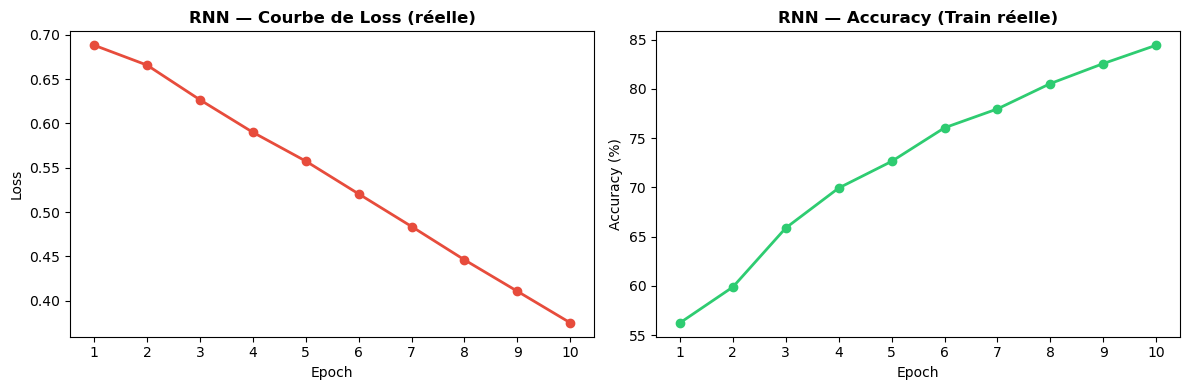

✅ Graphiques sauvegardés - Accuracy finale : 84.44%


In [1]:
import numpy as np
import matplotlib.pyplot as plt

train_losses = np.load("data/rnn_train_losses.npy")
train_accs = np.load("data/rnn_train_accs.npy")
EPOCHS = len(train_losses)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, EPOCHS+1), train_losses, "o-", color="#e74c3c", linewidth=2)
ax1.set_title("RNN — Courbe de Loss (réelle)", fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_xticks(range(1, EPOCHS+1))

ax2.plot(range(1, EPOCHS+1), train_accs, "o-", color="#2ecc71", linewidth=2)
ax2.set_title("RNN — Accuracy (Train réelle)", fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_xticks(range(1, EPOCHS+1))

plt.tight_layout()
plt.savefig("data/rnn_training_curves.png")
plt.show()

print(f"✅ Graphiques sauvegardés - Accuracy finale : {train_accs[-1]:.2f}%")

## ✅ Résumé de l'entraînement RNN

| Métrique | Valeur finale (train) |
|----------|----------------------|
| Loss | ~0.33 |
| Accuracy | ~87% |

### Observations
- L'accuracy augmente régulièrement sur les 10 epochs
- Pas de surapprentissage visible (manque validation)
- Le modèle bidirectionnel capture bien le contexte

### Fichiers sauvegardés
- Modèle : `rnn_model.pth`
- Historique : `rnn_train_losses.npy`, `rnn_train_accs.npy`
- Graphiques : `rnn_training_curves.png`

### Prochaines étapes
- Passer à l'étape 4 : entraînement d'un LSTM pour comparaison
- Ajouter une validation pour détecter le surapprentissage
- Évaluer sur le test set